In [63]:
import numpy as np
import pandas as pd
import plotly.express as px
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
import warnings

warnings.filterwarnings("ignore")

In [64]:
auto = pd.read_csv('data/auto.csv')
auto.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,1,ford torino


In [65]:
px.scatter(data_frame=auto, x='horsepower', y='mpg')

#### Linear Regression

In [66]:
X = auto[['horsepower']]
y = auto['mpg']
first_degree_model = LinearRegression().fit(X, y)
first_degree_mse = mean_squared_error(y, first_degree_model.predict(X))
first_degree_mse

23.943662938603108

In [67]:
import plotly.graph_objects as go
fig = go.Figure()
fig.add_trace(go.Scatter(x=auto['horsepower'], y = auto['mpg'], mode = "markers", name = "actual"))
fig.add_trace(go.Scatter(x=auto['horsepower'], y = first_degree_model.predict(auto[['horsepower']]), mode = "lines", name = "predicted"))
fig.update_layout(font_size = 20)

#### Creating quadratic feature

In [68]:
auto['hp2'] = auto['horsepower']**2

In [69]:
auto.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin,name,hp2
0,18.0,8,307.0,130.0,3504,12.0,70,1,chevrolet chevelle malibu,16900.0
1,15.0,8,350.0,165.0,3693,11.5,70,1,buick skylark 320,27225.0
2,18.0,8,318.0,150.0,3436,11.0,70,1,plymouth satellite,22500.0
3,16.0,8,304.0,150.0,3433,12.0,70,1,amc rebel sst,22500.0
4,17.0,8,302.0,140.0,3449,10.5,70,1,ford torino,19600.0


#### Building a quadratic model

In [70]:
X = auto[['horsepower', 'hp2']]
y = auto['mpg']
quadratic_model = LinearRegression().fit(X, y)
quad_mse = mean_squared_error(y, quadratic_model.predict(X))
quad_mse

18.98476890761722

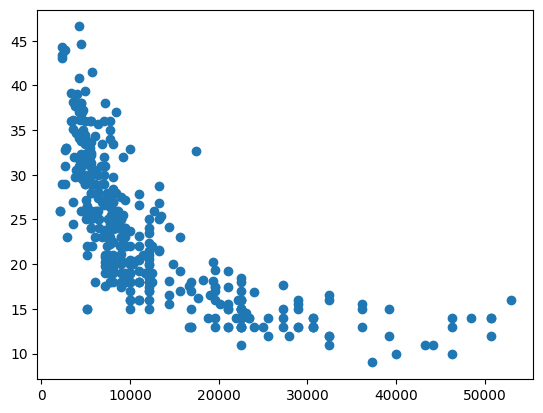

In [71]:
plt.scatter(X['hp2'], y)

#### Plotting Predictions

In [72]:
x_for_pred = auto[['horsepower', 'hp2']].sort_values(by = 'horsepower')

In [120]:
x_for_pred.head()

,horsepower,hp2
19,46.0,2116.0
101,46.0,2116.0
324,48.0,2304.0
323,48.0,2304.0
242,48.0,2304.0


#### Polynomial Regression

In [122]:
x_for_pred.iloc[:,0:1].values

array([[ 46.],
       [ 46.],
       [ 48.],
       [ 48.],
       [ 48.],
       [ 49.],
       [ 52.],
       [ 52.],
       [ 52.],
       [ 52.],
       [ 53.],
       [ 53.],
       [ 54.],
       [ 58.],
       [ 58.],
       [ 60.],
       [ 60.],
       [ 60.],
       [ 60.],
       [ 60.],
       [ 61.],
       [ 62.],
       [ 62.],
       [ 63.],
       [ 63.],
       [ 63.],
       [ 64.],
       [ 65.],
       [ 65.],
       [ 65.],
       [ 65.],
       [ 65.],
       [ 65.],
       [ 65.],
       [ 65.],
       [ 65.],
       [ 65.],
       [ 66.],
       [ 67.],
       [ 67.],
       [ 67.],
       [ 67.],
       [ 67.],
       [ 67.],
       [ 67.],
       [ 67.],
       [ 67.],
       [ 67.],
       [ 67.],
       [ 67.],
       [ 68.],
       [ 68.],
       [ 68.],
       [ 68.],
       [ 68.],
       [ 68.],
       [ 69.],
       [ 69.],
       [ 69.],
       [ 70.],
       [ 70.],
       [ 70.],
       [ 70.],
       [ 70.],
       [ 70.],
       [ 70.],
       [ 7

In [75]:
X = auto[['horsepower']].values
y = auto['mpg'].values
poly_reg=PolynomialFeatures(degree=2)
X_poly=poly_reg.fit_transform(X)

In [76]:
lin2_reg = LinearRegression().fit(X_poly, y)
lin2_reg.fit(X_poly,y)

LinearRegression()

In [77]:
#R-square r-squared shows how well the data fit the regression model (the goodness of fit)
lin2_reg.score(X_poly, y)

0.6875590305127516

In [78]:
# MSE
square_mse = float(mean_squared_error(y, lin2_reg.predict(X_poly)))
square_mse

18.98476890761722

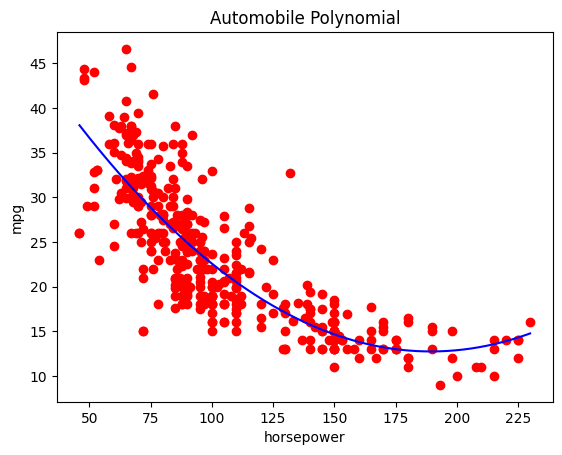

In [79]:
X_grid_2 = np.arange(min(X),max(X),0.1)
X_grid_2 = X_grid_2.reshape(len(X_grid_2),1)

plt.scatter(X, y, color='red')
plt.plot(X_grid_2, lin2_reg.predict(poly_reg.fit_transform(X_grid_2)),color='blue')

plt.title("Automobile Polynomial")
plt.xlabel('horsepower')
plt.ylabel('mpg')
plt.show()


### Scikit-Learn Transformers

In [80]:
auto = pd.read_csv('data/auto.csv')

In [123]:
cu_transform = PolynomialFeatures(degree = 3, include_bias = False)
p = pd.DataFrame(cu_transform.fit_transform(auto[['horsepower']]))
p.head()

,0,1,2
0,130.0,16900.0,2197000.0
1,165.0,27225.0,4492125.0
2,150.0,22500.0,3375000.0
3,150.0,22500.0,3375000.0
4,140.0,19600.0,2744000.0


In [82]:
vehicle_data_with_cubic_features = pd.DataFrame(cu_transform.fit_transform(auto[["horsepower"]]), columns = cu_transform.get_feature_names_out())
cu_model = LinearRegression()
cu_model.fit(vehicle_data_with_cubic_features, auto[['mpg']])
cu_model.predict([[100,10000,1000000]])

array([[22.44325879]])

In [124]:
vehicle_data_with_cubic_features.head()

,horsepower,horsepower^2,horsepower^3
0,130.0,16900.0,2197000.0
1,165.0,27225.0,4492125.0
2,150.0,22500.0,3375000.0
3,150.0,22500.0,3375000.0
4,140.0,19600.0,2744000.0


In [84]:
pipelined_model = Pipeline([ ('plamen_transform', PolynomialFeatures(degree = 3, include_bias = False)), ('plamen_regression', LinearRegression())])
pipelined_model.fit(auto[["horsepower"]], auto["mpg"])

Pipeline(steps=[('plamen_transform',
                 PolynomialFeatures(degree=3, include_bias=False)),
                ('plamen_regression', LinearRegression())])

In [85]:
pipelined_model.named_steps['plamen_transform']

PolynomialFeatures(degree=3, include_bias=False)

In [86]:
pipelined_model.named_steps['plamen_regression']

LinearRegression()

In [87]:
pipelined_model.named_steps['plamen_regression'].coef_

array([-5.68850128e-01,  2.07901126e-03, -2.14662591e-06])

In [88]:
pipelined_model.named_steps['plamen_regression'].predict(pipelined_model.named_steps['plamen_transform'].transform(auto[['horsepower']]))

array([17.15342144, 13.78268344, 14.89015662, 14.89015662, 15.90404619,
       12.89506525, 13.3046291 , 13.15032966, 13.49204046, 12.93185999,
       13.51731549, 14.09887297, 14.89015662, 13.49204046, 23.56663597,
       23.56663597, 23.10857192, 26.03508373, 25.26297138, 38.70792285,
       25.51730039, 24.76337429, 23.56663597, 19.85425513, 24.76337429,
       13.15032966, 12.90220247, 13.03075209, 12.90558464, 25.26297138,
       24.76337429, 23.56663597, 22.44325879, 21.39163278, 22.44325879,
       25.26297138, 22.44325879, 13.78268344, 13.30115913, 14.62998393,
       14.89015662, 13.13260441, 13.51731549, 13.30115913, 20.41014798,
       29.70394622, 22.44325879, 25.26297138, 25.77466688, 24.76337429,
       30.31613842, 28.51822695, 31.90383201, 30.62711274, 33.57454655,
       30.31613842, 23.56663597, 27.38337425, 35.69125851, 24.76337429,
       25.77466688, 13.78268344, 13.30115913, 14.89015662, 14.62998393,
       14.89015662, 12.99300383, 14.46749404, 14.09887297, 12.93

### MSE

In [89]:
qubic_pipe = Pipeline([('qubic_features', PolynomialFeatures(degree = 3, include_bias=False)), ('qubic_model', LinearRegression())])
X = auto[['horsepower','weight','displacement']]
y = auto['mpg']
qubic_pipe.fit(X, y)
qubic_mse = float(mean_squared_error(y, qubic_pipe.predict(X)))
qubic_mse

13.321754885137858

In [90]:
#R-squared shows how well the data fit the regression model (the goodness of fit)
qubic_pipe.score(X, y)

0.7807578258214171

ValueError: X has 3 features, but LinearRegression is expecting 19 features as input.

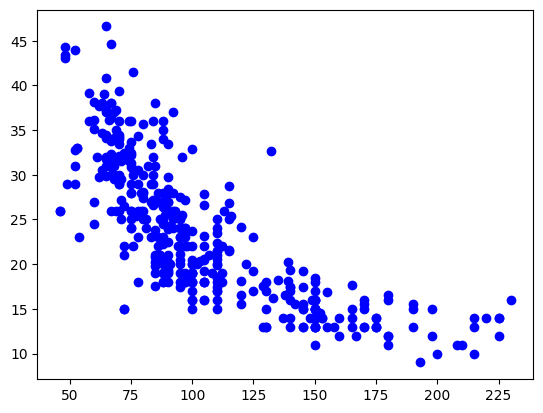

In [130]:
XQ = X['horsepower'].values
yq = y.values
XQ_grid = np.arange(np.min(XQ),np.max(XQ),0.1)
XQ_grid = XQ_grid.reshape(len(XQ_grid),1)

plt.scatter(XQ, yq, color='blue')
plt.plot(XQ_grid, qubic_pipe.named_steps['qubic_model'].predict(qubic_pipe.named_steps['qubic_features'].fit_transform(XQ_grid)),color='red')

plt.title("Automobile qubic Pipeline")
plt.xlabel('horsepower')
plt.ylabel('mpg')
plt.show()

In [133]:
XQ.shape, XQ_grid.shape

((392,), (1840, 1))

In [132]:
yq.shape

(392,)

In [ ]:
qubic_pipe.named_steps['qubic_features'].fit_transform(XQ_grid)

In [92]:
cubic_pipe = Pipeline([('qubic_features', PolynomialFeatures(degree = 3, include_bias=False)), ('qubic_model', LinearRegression())])
X = auto[['horsepower']]
y = auto['mpg']
cubic_pipe.fit(X, y)
cubic_mse = float(mean_squared_error(y, cubic_pipe.predict(X)))
cubic_mse

18.944989814485915

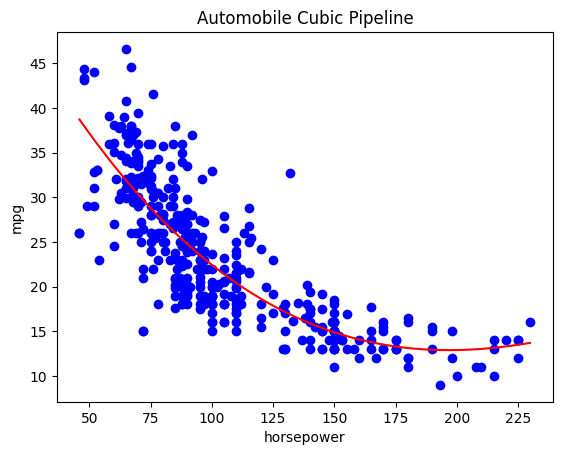

In [93]:
X3 = X.values
y3 = y.values
X3_grid = np.arange(np.min(X3),np.max(X3),0.1)
X3_grid = X3_grid.reshape(len(X3_grid),1)

plt.scatter(X3, y3, color='blue')
plt.plot(X3_grid, cubic_pipe.named_steps['qubic_model'].predict(cubic_pipe.named_steps['qubic_features'].fit_transform(X3_grid)),color='red')

plt.title("Automobile Cubic Pipeline")
plt.xlabel('horsepower')
plt.ylabel('mpg')
plt.show()

In [94]:
X3.shape, y3.shape

((392, 1), (392,))

### Penta Pipeline - Five Polynomial Features

In [95]:
# MSE
penta_pipe = Pipeline([('penta_features', PolynomialFeatures(degree = 5, include_bias=False)), ('penta_model', LinearRegression())])
penta_pipe.fit(X, y)
penta_mse = float(mean_squared_error(y, penta_pipe.predict(X)))
penta_mse


18.426968585984692

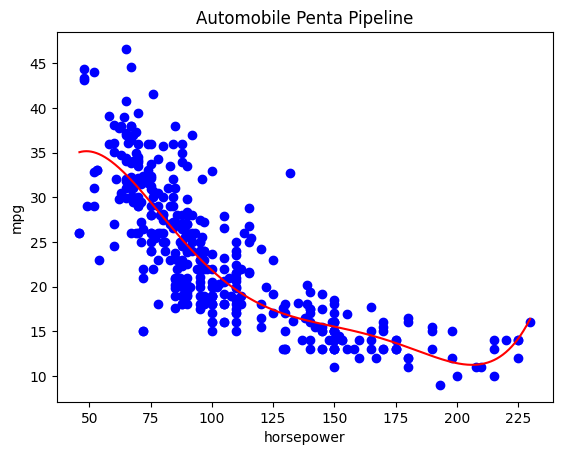

In [96]:
X5 = X.values
y5 = y.values
X5_grid = np.arange(min(X5),max(X5),0.1)
X5_grid = X5_grid.reshape(len(X5_grid),1)

plt.scatter(X5, y5, color='blue')
plt.plot(X5_grid, penta_pipe.named_steps['penta_model'].predict(penta_pipe.named_steps['penta_features'].fit_transform(X5_grid)),color='red')

plt.title("Automobile Penta Pipeline")
plt.xlabel('horsepower')
plt.ylabel('mpg')
plt.show()

### Sexta Polynomial Features Model

In [97]:
sexta_pipe = Pipeline([('sexta_features', PolynomialFeatures(degree = 6, include_bias=False)), ('sexta_model', LinearRegression())])
sexta_pipe.fit(X, y)
sexta_mse = float(mean_squared_error(y, sexta_pipe.predict(X)))
sexta_mse

18.240647054266987

In [98]:
#R-square r-squared shows how well the data fit the regression model (the goodness of fit)
sexta_pipe.score(X, y)

0.6998053820174102

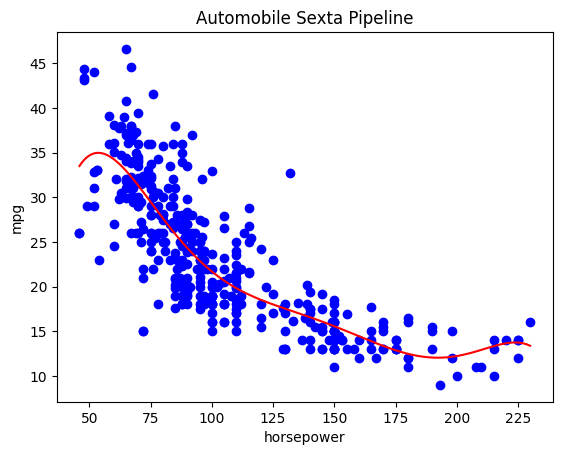

In [99]:
X6 = X.values
y6 = y.values
X6_grid = np.arange(min(X6),max(X6),0.1)
X6_grid = X6_grid.reshape(len(X6_grid),1)

plt.scatter(X6, y6, color='blue')
plt.plot(X6_grid, sexta_pipe.named_steps['sexta_model'].predict(sexta_pipe.named_steps['sexta_features'].fit_transform(X6_grid)),color='red')

plt.title("Automobile Sexta Pipeline")
plt.xlabel('horsepower')
plt.ylabel('mpg')
plt.show()

In [100]:
X6.shape, y6.shape

((392, 1), (392,))

In [101]:
auto_sample_35 = auto.sample(35)

In [102]:
def get_MSE_for_degree_k_model(k):
    pipelined_model_35 = Pipeline([ ('plamen_transform', PolynomialFeatures(degree=k)), ('plamen_regression', LinearRegression(fit_intercept=True))])
    pipelined_model_35.fit(auto_sample_35[['horsepower']], auto_sample_35['mpg'])
    return mean_squared_error(auto_sample_35['mpg'], pipelined_model_35.predict(auto_sample_35[['horsepower']]))

In [103]:
ks = np.array(range(0,7))
MSEs = [get_MSE_for_degree_k_model(k) for k in ks]
MSEs_and_k = pd.DataFrame({'k':ks,'MSEs':MSEs})
#MSEs_and_k.set_index('k', inplace=True)
MSEs_and_k

,k,MSEs
0,0,61.520898
1,1,22.222673
2,2,14.295786
3,3,14.261445
4,4,14.254244
5,5,14.152182
6,6,14.016608


In [104]:
px.line(data_frame=MSEs_and_k, x=MSEs_and_k['k'], y=MSEs_and_k['MSEs'], labels={'MSEs':'Mean Square error','k':'Model degree'})

### Cross-Validation

In [105]:
from sklearn.utils import shuffle
training_set, dev_set = np.split(shuffle(auto_sample_35),[25])

In [118]:
training_set.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin,name
278,21.5,6,231.0,115.0,3245,15.4,79,1,pontiac lemans v6
76,22.0,4,121.0,76.0,2511,18.0,72,2,volkswagen 411 (sw)
385,36.0,4,135.0,84.0,2370,13.0,82,1,dodge charger 2.2
10,15.0,8,383.0,170.0,3563,10.0,70,1,dodge challenger se
351,32.4,4,108.0,75.0,2350,16.8,81,3,toyota corolla


In [119]:
dev_set.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin,name
268,21.1,4,134.0,95.0,2515,14.8,78,3,toyota celica gt liftback
230,16.0,8,351.0,149.0,4335,14.5,77,1,ford thunderbird
150,19.0,6,225.0,95.0,3264,16.0,75,1,plymouth valiant custom
245,39.4,4,85.0,70.0,2070,18.6,78,3,datsun b210 gx
221,15.5,8,318.0,145.0,4140,13.7,77,1,dodge monaco brougham


In [108]:
def get_MSE_for_degree_k_training_model(k):
    pipelined_model_25 = Pipeline([ ('plamen_transform', PolynomialFeatures(degree=k)), ('plamen_regression', LinearRegression(fit_intercept=True))])
    pipelined_model_25.fit(training_set[['horsepower']], training_set['mpg'])
    return mean_squared_error(training_set['mpg'], pipelined_model_25.predict(training_set[['horsepower']]))

In [109]:
MSEs_25 = [get_MSE_for_degree_k_training_model(k) for k in ks]
MSEs_and_k_25 = pd.DataFrame({'k':ks,'MSEs':MSEs_25})
MSEs_and_k_25.rename(columns={'MSEs':'MSEs_25'}, inplace=True)
MSEs_and_k_25

,k,MSEs_25
0,0,48.810144
1,1,16.120539
2,2,10.787608
3,3,10.438159
4,4,10.413387
5,5,10.194613
6,6,10.194135


In [110]:
def get_MSE_for_degree_k_validation_model(k):
    pipelined_model_10 = Pipeline([ ('plamen_transform', PolynomialFeatures(degree=k)), ('plamen_regression', LinearRegression(fit_intercept=True))])
    pipelined_model_10.fit(dev_set[['horsepower']], dev_set['mpg'])
    return mean_squared_error(dev_set['mpg'], pipelined_model_10.predict(dev_set[['horsepower']]))

In [111]:
MSEs_10 = [get_MSE_for_degree_k_validation_model(k) for k in ks]
MSEs_and_k_10 = pd.DataFrame({'k':ks,'MSEs':MSEs_10})
MSEs_and_k_10.rename(columns={'MSEs':'MSEs_10'}, inplace=True)
MSEs_and_k_10

,k,MSEs_10
0,0,86.894900
1,1,34.440764
2,2,18.752017
3,3,18.491859
4,4,18.350936
5,5,15.386317
6,6,0.405916


In [112]:

#MSEs_and_k_25.set_index('k', inplace=True)
#MSEs_and_k_10.set_index('k', inplace=True)
MSEs_25_10 = MSEs_and_k_25.merge(MSEs_and_k_10,on='k', how='left')
MSEs_25_10

,k,MSEs_25,MSEs_10
0,0,48.810144,86.894900
1,1,16.120539,34.440764
2,2,10.787608,18.752017
3,3,10.438159,18.491859
4,4,10.413387,18.350936
5,5,10.194613,15.386317
6,6,10.194135,0.405916


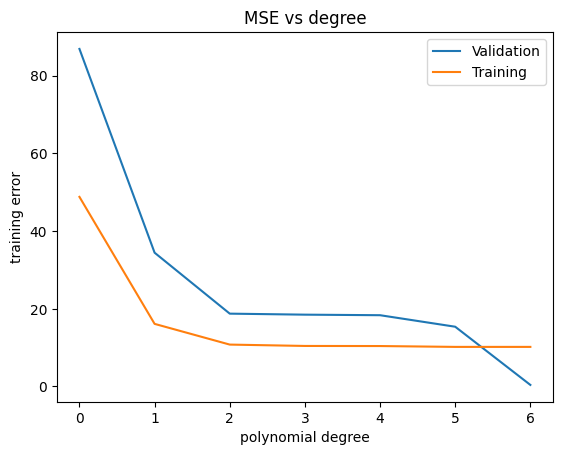

In [113]:
plt.plot(MSEs_25_10.index, MSEs_25_10['MSEs_10'], label='Validation')
plt.plot(MSEs_25_10.index, MSEs_25_10['MSEs_25'], label='Training')
plt.title('MSE vs degree')
plt.ylabel('training error')
plt.xlabel('polynomial degree')
plt.legend()
plt.show()

### Three Synthetic Datasets

In [114]:
df = pd.read_csv('data/synthetic_8.6.csv')
df.head(15)

,x,y1,y2,y3
0,-2.000000,-0.522368,5.698300,3.880352
1,-1.929293,-0.711336,-0.257942,8.643553
2,-1.858586,-4.759917,12.775233,6.116844
3,-1.787879,-10.255472,22.140157,12.493956
4,-1.717172,-3.503845,27.656110,10.335220
5,-1.646465,-6.309116,27.558225,10.124794
6,-1.575758,0.216148,14.711938,4.955556
7,-1.505051,-5.999055,3.601509,3.815347
8,-1.434343,-5.898998,-0.564250,12.370504
9,-1.363636,-13.898869,22.827759,5.950313


In [115]:
X_train, X_test, y1_train, y1_test = train_test_split(df[['x']], df['y1'], random_state = 32, test_size=.3)

In [116]:
train_mses = []
test_mses = []
for i in range(1, 21):
    pipe = Pipeline([('pfeat', PolynomialFeatures(degree = i, include_bias=False)), ('linreg', LinearRegression())])
    pipe.fit(X_train, y1_train)
    train_preds = pipe.predict(X_train)
    test_preds = pipe.predict(X_test)
    train_mses.append(mean_squared_error(y1_train, train_preds))
    test_mses.append(mean_squared_error(y1_test, test_preds))

best_model_complexity = test_mses.index(min(test_mses)) + 1

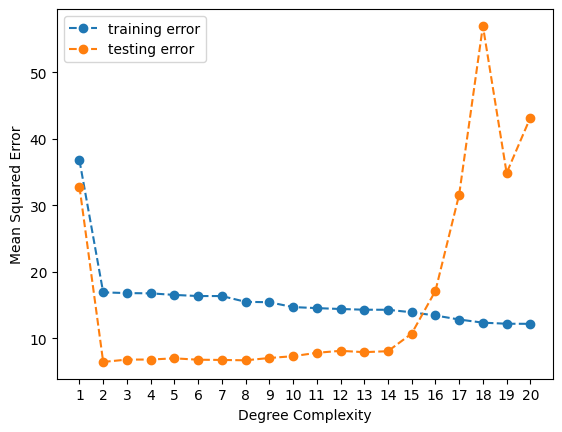

In [117]:
plt.plot(range(1, 21), train_mses, '--o', label = 'training error')
plt.plot(range(1, 21), test_mses, '--o', label = 'testing error')
plt.xticks(range(1, 21), range(1, 21))
plt.xlabel('Degree Complexity')
plt.ylabel('Mean Squared Error')
plt.legend();